# DO Card Classifier Training

Train a simple full-card classifier using the data produced by the DO notebooks: reference card crops, augmented card crops, and labeled crops from augmented scenes. The notebook saves a single classifier that predicts labels such as `r_5`, `wild`, or `draw_4` directly.

In [26]:
from __future__ import annotations

import csv
import json
import random
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import hog as skimage_hog
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().resolve()
while not ((PROJECT_ROOT / "project" / "training_data").exists() and (PROJECT_ROOT / "data").exists()):
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not locate workspace root containing project/training_data and data/.")
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_DIR = PROJECT_ROOT / "project"
TRAINING_DATA = PROJECT_DIR / "training_data"
MODELS_DIR = PROJECT_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_CSV = TRAINING_DATA / "object_labels" / "reference_cards" / "reference_do.csv"
AUG_CSV = TRAINING_DATA / "object_labels" / "augmented_cards" / "aug.csv"
SCENE_LABELS_PATH = TRAINING_DATA / "object_labels" / "augmented_scenes" / "labels.json"

REF_CARDS_DIR = TRAINING_DATA / "training_images" / "reference_cards"
AUG_CARDS_DIR = TRAINING_DATA / "training_images" / "augmented_cards"
SCENE_IMAGES_DIR = TRAINING_DATA / "training_images" / "augmented_scenes"

CARD_CLF_PATH = MODELS_DIR / "card_clf_do.pkl"
CARD_CLASSES_PATH = MODELS_DIR / "card_classes_do.npy"
CARD_CONFIG_PATH = MODELS_DIR / "card_classifier_do_config.json"

for required_path in (REFERENCE_CSV, REF_CARDS_DIR):
    if not required_path.exists():
        raise FileNotFoundError(f"Missing required classifier input: {required_path}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Reference labels: {REFERENCE_CSV}")
print(f"Augmented labels: {AUG_CSV}")
print(f"Scene labels:     {SCENE_LABELS_PATH}")
print(f"Model output:     {CARD_CLF_PATH}")

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do
Reference labels: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\object_labels\reference_cards\reference_do.csv
Augmented labels: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\object_labels\augmented_cards\aug.csv
Scene labels:     C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\object_labels\augmented_scenes\labels.json
Model output:     C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\card_clf_do.pkl


## Helper Functions

The classifier uses one feature vector per crop: HSV color histograms for color plus HOG and simple Fourier contour descriptors for rank/symbol shape.

In [27]:
IMG_SIZE = 128
FOURIER_COEFFS = 32


@dataclass(frozen=True)
class CardSample:
    source: str
    label: str
    image_path: Path
    bbox: tuple[int, int, int, int] | None = None


def clean_label(label: str) -> str:
    return str(label).strip()


def resolve_project_path(path_value: str | Path) -> Path:
    path = Path(path_value)
    return path if path.is_absolute() else PROJECT_ROOT / path


def reference_crop_path(image_id: str) -> Path:
    tag, separator, crop_index = image_id.rpartition("_crop_")
    if separator == "":
        raise ValueError(f"Unexpected reference image_id: {image_id}")
    return REF_CARDS_DIR / tag / "crops" / f"crop_{crop_index}.jpg"


def crop_with_margin(img_bgr: np.ndarray, bbox: tuple[int, int, int, int], margin_fraction: float = 0.08) -> np.ndarray:
    x0, y0, x1, y1 = map(int, bbox)
    h, w = img_bgr.shape[:2]
    bw = max(1, x1 - x0)
    bh = max(1, y1 - y0)
    margin = int(round(margin_fraction * max(bw, bh)))
    x0 = max(0, x0 - margin)
    y0 = max(0, y0 - margin)
    x1 = min(w, x1 + margin)
    y1 = min(h, y1 + margin)
    return img_bgr[y0:y1, x0:x1]


def read_sample_bgr(sample: CardSample) -> np.ndarray:
    img_bgr = cv2.imread(str(sample.image_path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read image: {sample.image_path}")
    if sample.bbox is not None:
        img_bgr = crop_with_margin(img_bgr, sample.bbox)
    return img_bgr


def letterbox_cv2(img_bgr: np.ndarray, size: int = IMG_SIZE, fill: int = 128) -> np.ndarray:
    h, w = img_bgr.shape[:2]
    scale = size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    resized = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((size, size, 3), fill, dtype=np.uint8)
    y0 = (size - new_h) // 2
    x0 = (size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas


def extract_color_feat(img_bgr: np.ndarray) -> np.ndarray:
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    saturated = ((hsv[:, :, 1] > 35) & (hsv[:, :, 2] > 40)).astype(np.uint8) * 255
    if int(saturated.sum()) == 0:
        saturated = None

    h_hist = cv2.calcHist([hsv], [0], saturated, [36], [0, 180]).flatten()
    s_hist = cv2.calcHist([hsv], [1], saturated, [16], [0, 256]).flatten()
    v_hist = cv2.calcHist([hsv], [2], saturated, [8], [0, 256]).flatten()
    feat = np.concatenate([h_hist, s_hist, v_hist]).astype(np.float32)
    return feat / (feat.sum() + 1e-6)


def extract_hog_feat(img_bgr: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return skimage_hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
    ).astype(np.float32)


def extract_fourier_feat(img_bgr: np.ndarray, n_coeffs: int = FOURIER_COEFFS) -> np.ndarray:
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    border = 8
    bw[:border, :] = 0
    bw[-border:, :] = 0
    bw[:, :border] = 0
    bw[:, -border:] = 0

    contours, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.zeros(n_coeffs, dtype=np.float32)

    contour = max(contours, key=cv2.contourArea)
    pts = contour[:, 0, :].astype(np.float32)
    if len(pts) < max(10, n_coeffs + 1):
        return np.zeros(n_coeffs, dtype=np.float32)

    z = pts[:, 0] + 1j * pts[:, 1]
    z = z - np.mean(z)
    magnitude = np.abs(np.fft.fft(z))[1:n_coeffs + 1]
    if len(magnitude) < n_coeffs:
        magnitude = np.pad(magnitude, (0, n_coeffs - len(magnitude)))
    magnitude = magnitude / (magnitude[0] + 1e-6)
    return magnitude.astype(np.float32)


def extract_features(img_bgr: np.ndarray) -> np.ndarray:
    img_lb = letterbox_cv2(img_bgr)
    return np.concatenate([
        extract_color_feat(img_lb),
        extract_hog_feat(img_lb),
        extract_fourier_feat(img_lb),
    ]).astype(np.float32)


print("Feature helpers ready.")

Feature helpers ready.


## Build Training Samples

This merges the three useful DO data sources. Scene crops use the bounding boxes stored in the augmented scene metadata.

In [28]:
samples: list[CardSample] = []
missing: list[str] = []

# 1) Reference crops from create_reference_cards_do.ipynb.
reference_labels: dict[str, str] = {}
with REFERENCE_CSV.open(newline="", encoding="utf-8") as csv_file:
    for row in csv.DictReader(csv_file):
        image_id = str(row["image_id"]).strip()
        label = clean_label(row["card"])
        if image_id and label:
            reference_labels[image_id] = label

for image_id, label in reference_labels.items():
    image_path = reference_crop_path(image_id)
    if image_path.is_file():
        samples.append(CardSample("reference", label, image_path))
    else:
        missing.append(str(image_path))

# 2) Augmented card crops from create_augmented_data_do.ipynb.
if AUG_CSV.is_file():
    with AUG_CSV.open(newline="", encoding="utf-8") as csv_file:
        for row in csv.DictReader(csv_file):
            image_id = str(row["image_id"]).strip()
            label = clean_label(row["card"])
            if not image_id or not label or label == "token":
                continue
            image_path = AUG_CARDS_DIR / f"{image_id}.jpg"
            if image_path.is_file():
                samples.append(CardSample("augmented_card", label, image_path))
            else:
                missing.append(str(image_path))
else:
    print(f"[warning] Augmented card CSV not found: {AUG_CSV}")

# 3) Card crops from augmented scenes, using labels.json metadata.
if SCENE_LABELS_PATH.is_file():
    with SCENE_LABELS_PATH.open("r", encoding="utf-8") as labels_file:
        scene_metadata = json.load(labels_file)

    for scene_entry in scene_metadata:
        scene_path = resolve_project_path(scene_entry.get("image_path", SCENE_IMAGES_DIR / f"{scene_entry['scene']}.jpg"))
        if not scene_path.is_file():
            missing.append(str(scene_path))
            continue
        for card in scene_entry.get("cards", []):
            label = clean_label(card.get("label", ""))
            bbox = tuple(map(int, card.get("bbox", [])))
            if label and len(bbox) == 4:
                samples.append(CardSample("augmented_scene", label, scene_path, bbox))
else:
    print(f"[warning] Augmented scene labels not found: {SCENE_LABELS_PATH}")

source_counts = Counter(sample.source for sample in samples)
label_counts = Counter(sample.label for sample in samples)

print(f"Total samples: {len(samples)}")
print(f"By source: {dict(source_counts)}")
print(f"Classes: {len(label_counts)}")
print(f"Smallest class counts: {label_counts.most_common()[-8:]}")
if missing:
    print(f"Missing files skipped: {len(missing)}")
    print("First few missing files:")
    for item in missing[:5]:
        print(f"  {item}")

if len(samples) == 0:
    raise RuntimeError("No classifier samples were found. Run the reference and augmentation notebooks first.")

Total samples: 7605
By source: {'reference': 54, 'augmented_card': 1080, 'augmented_scene': 6471}
Classes: 53
Smallest class counts: [('g_3', 126), ('g_1', 126), ('r_2', 125), ('g_7', 125), ('y_reverse', 122), ('r_4', 120), ('g_5', 119), ('g_8', 118)]


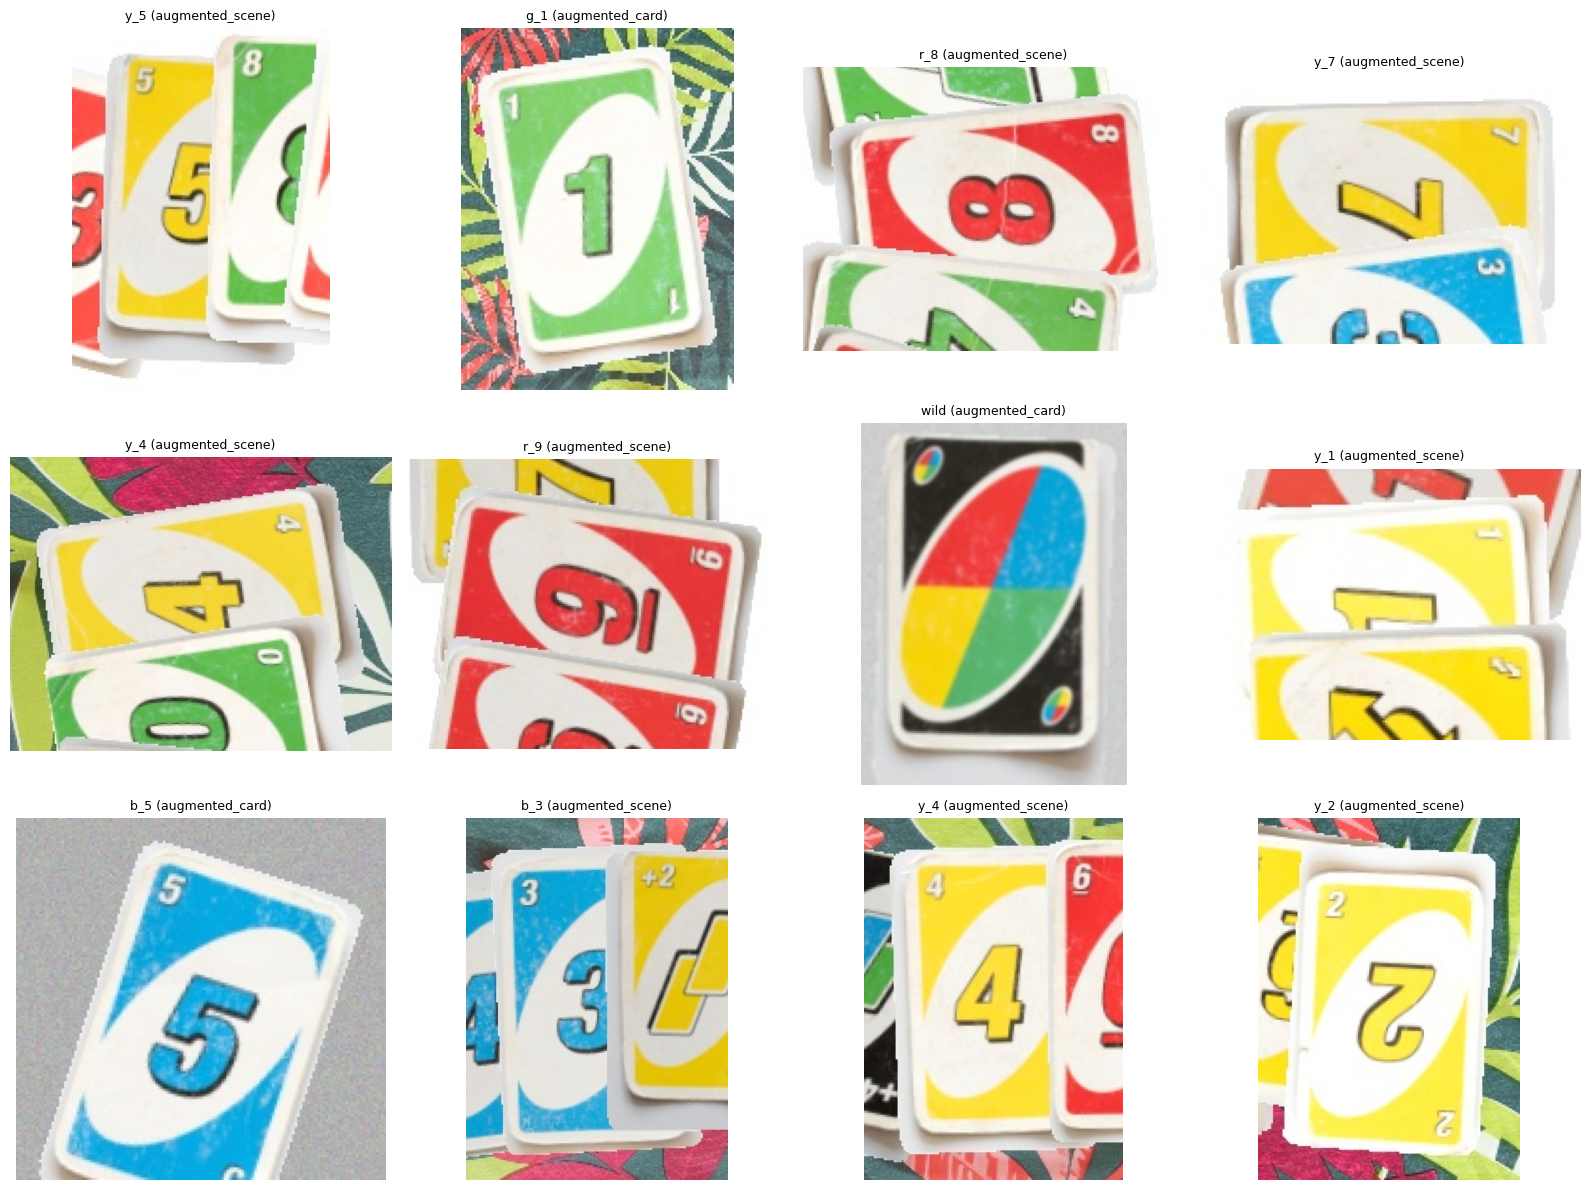

In [29]:
# Quick visual check of the mixed training set.
preview_count = min(12, len(samples))
preview_rng = np.random.default_rng(SEED)
preview_indices = preview_rng.choice(len(samples), size=preview_count, replace=False)

cols = 4
rows = int(np.ceil(preview_count / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, sample_index in zip(axes, preview_indices):
    sample = samples[int(sample_index)]
    img_bgr = read_sample_bgr(sample)
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{sample.label} ({sample.source})", fontsize=9)
    ax.axis("off")

for ax in axes[preview_count:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Extract Features And Train

ExtraTrees works well here because the dataset is small, mixed, and mostly tabular after feature extraction. Training should stay easy to inspect and rerun.

In [30]:
features: list[np.ndarray] = []
labels: list[str] = []
valid_samples: list[CardSample] = []

print(f"Extracting features from {len(samples)} samples...")
for index, sample in enumerate(samples, start=1):
    img_bgr = read_sample_bgr(sample)
    if img_bgr.size == 0:
        continue
    features.append(extract_features(img_bgr))
    labels.append(sample.label)
    valid_samples.append(sample)
    if index % 500 == 0 or index == len(samples):
        print(f"  {index}/{len(samples)}")

X = np.vstack(features)
labels = np.array(labels)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

print(f"Feature matrix: {X.shape}")
print(f"Classes ({len(label_encoder.classes_)}): {list(label_encoder.classes_)}")

min_class_count = min(Counter(y).values())
stratify_y = y if min_class_count >= 2 else None
if stratify_y is None:
    print("[warning] Some classes have only one sample; validation split will not be stratified.")

train_idx, val_idx = train_test_split(
    np.arange(len(y)),
    test_size=0.20,
    random_state=SEED,
    stratify=stratify_y,
)

card_clf = ExtraTreesClassifier(
    n_estimators=700,
    max_features="sqrt",
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)

card_clf.fit(X[train_idx], y[train_idx])

train_pred = card_clf.predict(X[train_idx])
val_pred = card_clf.predict(X[val_idx])
train_acc = accuracy_score(y[train_idx], train_pred)
val_acc = accuracy_score(y[val_idx], val_pred)

print(f"Train samples: {len(train_idx)} | Val samples: {len(val_idx)}")
print(f"Train accuracy: {train_acc * 100:.1f}%")
print(f"Val accuracy:   {val_acc * 100:.1f}%")

Extracting features from 7605 samples...
  500/7605
  1000/7605
  1500/7605
  2000/7605
  2500/7605
  3000/7605
  3500/7605
  4000/7605
  4500/7605
  5000/7605
  5500/7605
  6000/7605
  6500/7605
  7000/7605
  7500/7605
  7605/7605
Feature matrix: (7605, 1856)
Classes (53): [np.str_('b_0'), np.str_('b_1'), np.str_('b_3'), np.str_('b_4'), np.str_('b_5'), np.str_('b_6'), np.str_('b_7'), np.str_('b_8'), np.str_('b_9'), np.str_('b_draw_2'), np.str_('b_reverse'), np.str_('b_skip'), np.str_('draw_4'), np.str_('g_0'), np.str_('g_1'), np.str_('g_2'), np.str_('g_3'), np.str_('g_4'), np.str_('g_5'), np.str_('g_6'), np.str_('g_7'), np.str_('g_8'), np.str_('g_9'), np.str_('g_draw_2'), np.str_('g_reverse'), np.str_('g_skip'), np.str_('r_0'), np.str_('r_1'), np.str_('r_2'), np.str_('r_3'), np.str_('r_4'), np.str_('r_5'), np.str_('r_6'), np.str_('r_7'), np.str_('r_8'), np.str_('r_9'), np.str_('r_draw_2'), np.str_('r_reverse'), np.str_('r_skip'), np.str_('wild'), np.str_('y_0'), np.str_('y_1'), np.str

In [31]:
# Save the DO classifier and the small bit of metadata needed by test_classifier_do.ipynb.
joblib.dump(card_clf, CARD_CLF_PATH)
np.save(CARD_CLASSES_PATH, label_encoder.classes_)

config = {
    "model_file": CARD_CLF_PATH.name,
    "classes_file": CARD_CLASSES_PATH.name,
    "image_size": IMG_SIZE,
    "fourier_coeffs": FOURIER_COEFFS,
    "feature_order": ["hsv_histogram", "hog", "fourier_contour"],
    "classifier": "ExtraTreesClassifier",
    "n_samples": int(len(valid_samples)),
    "source_counts": dict(source_counts),
    "validation_accuracy": float(val_acc),
    "seed": SEED,
}
with CARD_CONFIG_PATH.open("w", encoding="utf-8") as config_file:
    json.dump(config, config_file, indent=2)

print(f"Saved classifier: {CARD_CLF_PATH}")
print(f"Saved classes:    {CARD_CLASSES_PATH}")
print(f"Saved config:     {CARD_CONFIG_PATH}")

Saved classifier: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\card_clf_do.pkl
Saved classes:    C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\card_classes_do.npy
Saved config:     C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\card_classifier_do_config.json


## Validation Diagnostics

              precision    recall  f1-score   support

         b_0       0.82      1.00      0.90        32
         b_1       0.97      1.00      0.98        30
         b_3       1.00      0.92      0.96        25
         b_4       0.93      0.90      0.91        29
         b_5       0.89      0.86      0.87        28
         b_6       1.00      0.78      0.88        27
         b_7       0.94      1.00      0.97        32
         b_8       0.94      1.00      0.97        33
         b_9       0.96      0.89      0.93        28
    b_draw_2       1.00      1.00      1.00        28
   b_reverse       0.96      0.93      0.95        29
      b_skip       1.00      0.93      0.96        28
      draw_4       1.00      1.00      1.00        29
         g_0       0.97      0.97      0.97        30
         g_1       0.89      0.96      0.92        25
         g_2       0.93      0.90      0.91        29
         g_3       0.96      0.92      0.94        25
         g_4       1.00    

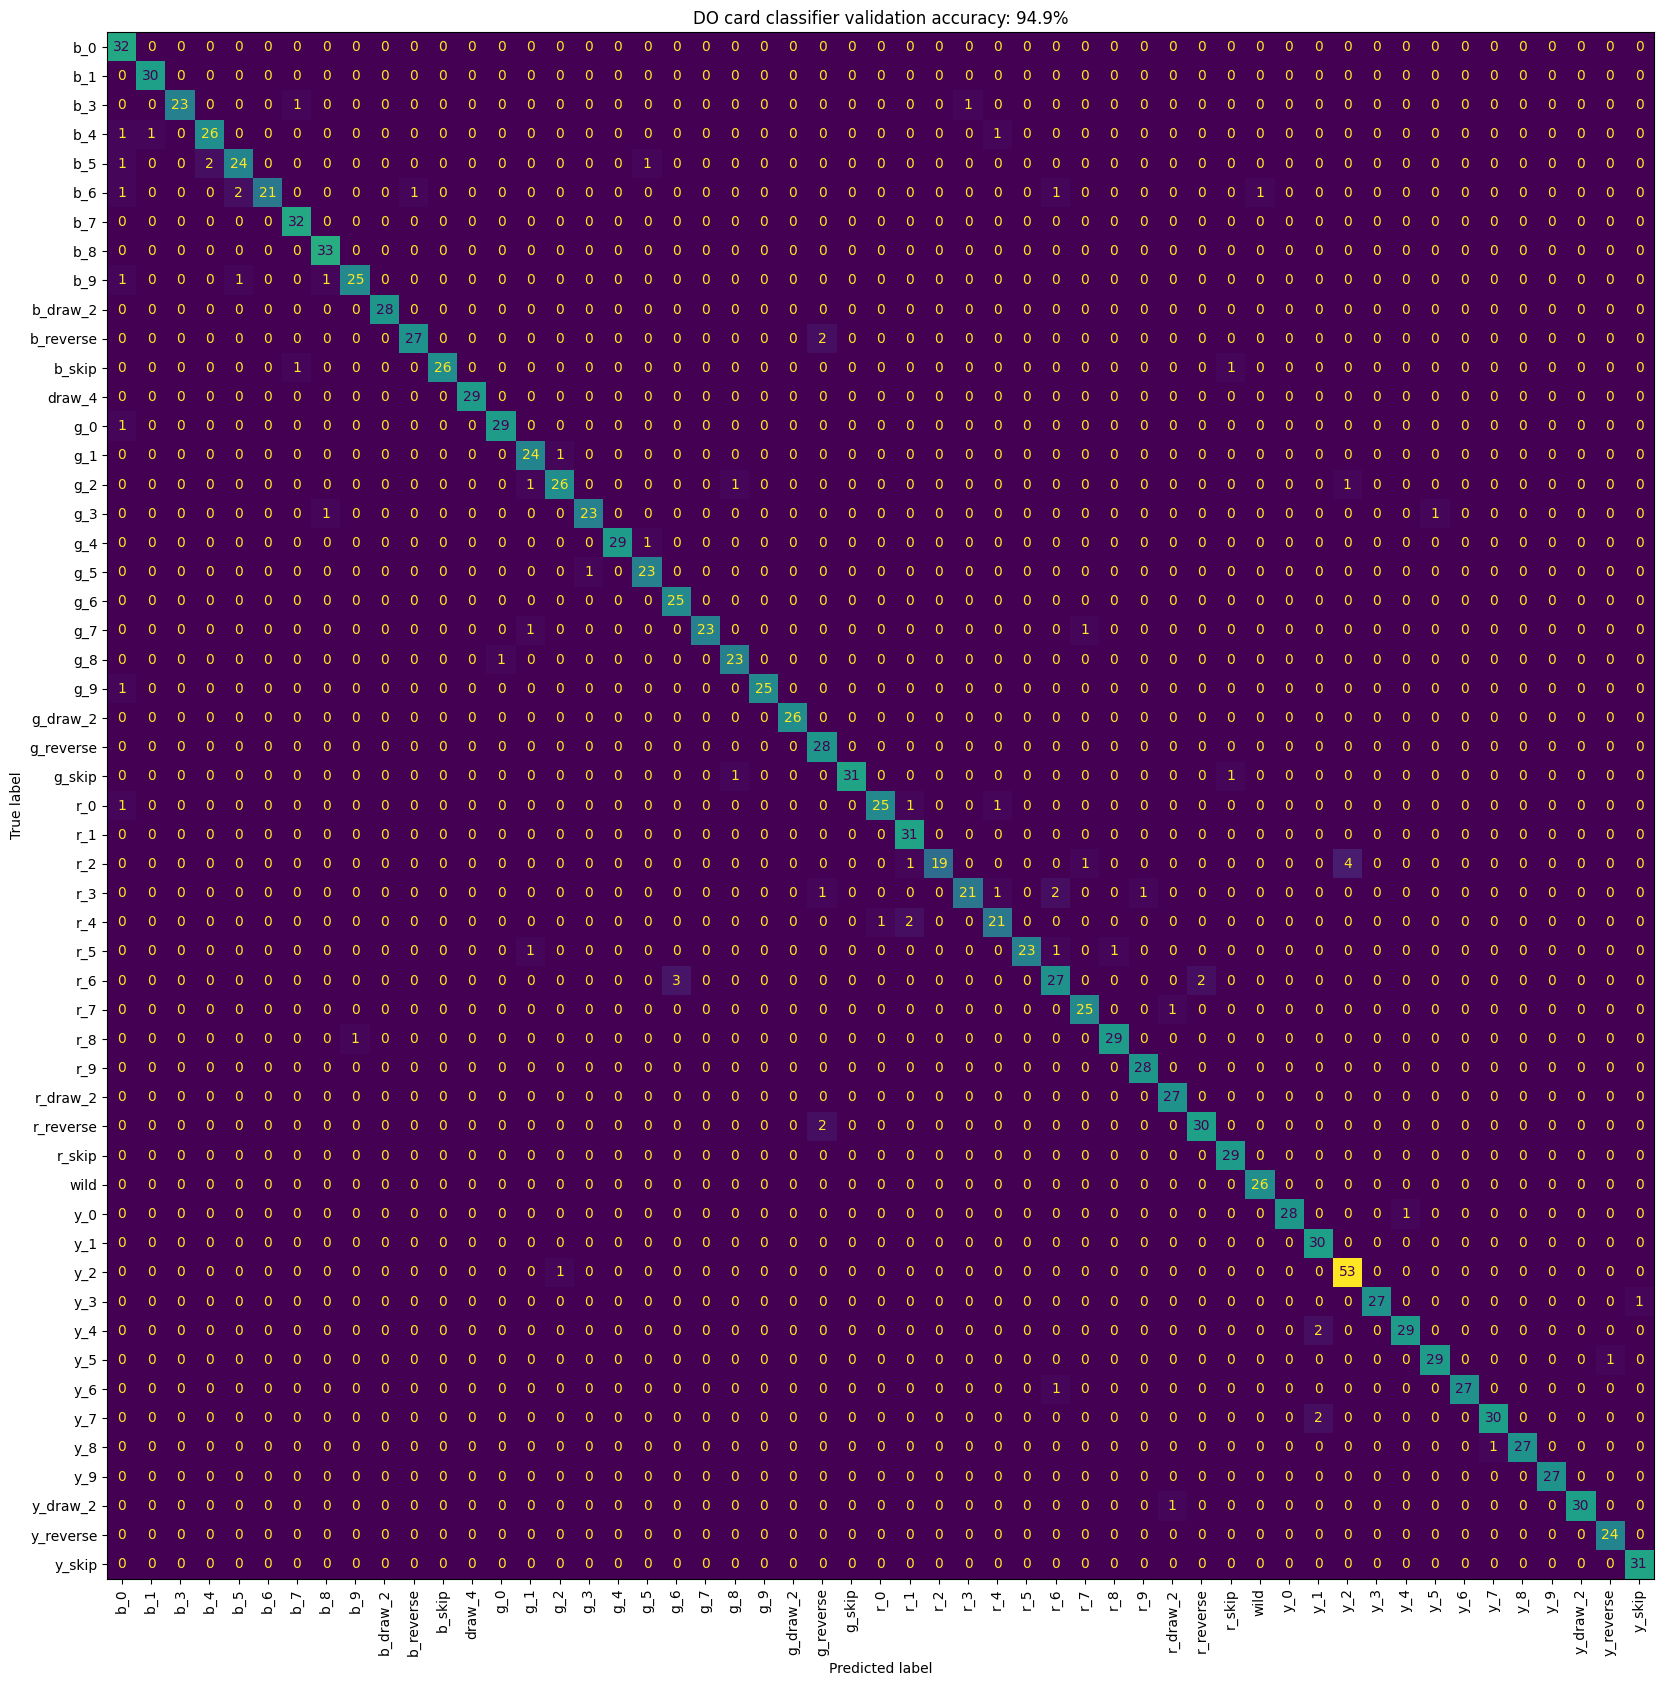

In [32]:
true_labels = label_encoder.inverse_transform(y[val_idx])
pred_labels = label_encoder.inverse_transform(val_pred)

print(classification_report(true_labels, pred_labels, zero_division=0))

fig_size = max(8, 0.32 * len(label_encoder.classes_))
fig, ax = plt.subplots(figsize=(fig_size, fig_size))
ConfusionMatrixDisplay.from_predictions(
    true_labels,
    pred_labels,
    labels=label_encoder.classes_,
    xticks_rotation=90,
    colorbar=False,
    ax=ax,
)
ax.set_title(f"DO card classifier validation accuracy: {val_acc * 100:.1f}%")
plt.tight_layout()
plt.show()

Wrong validation predictions: 77 / 1521


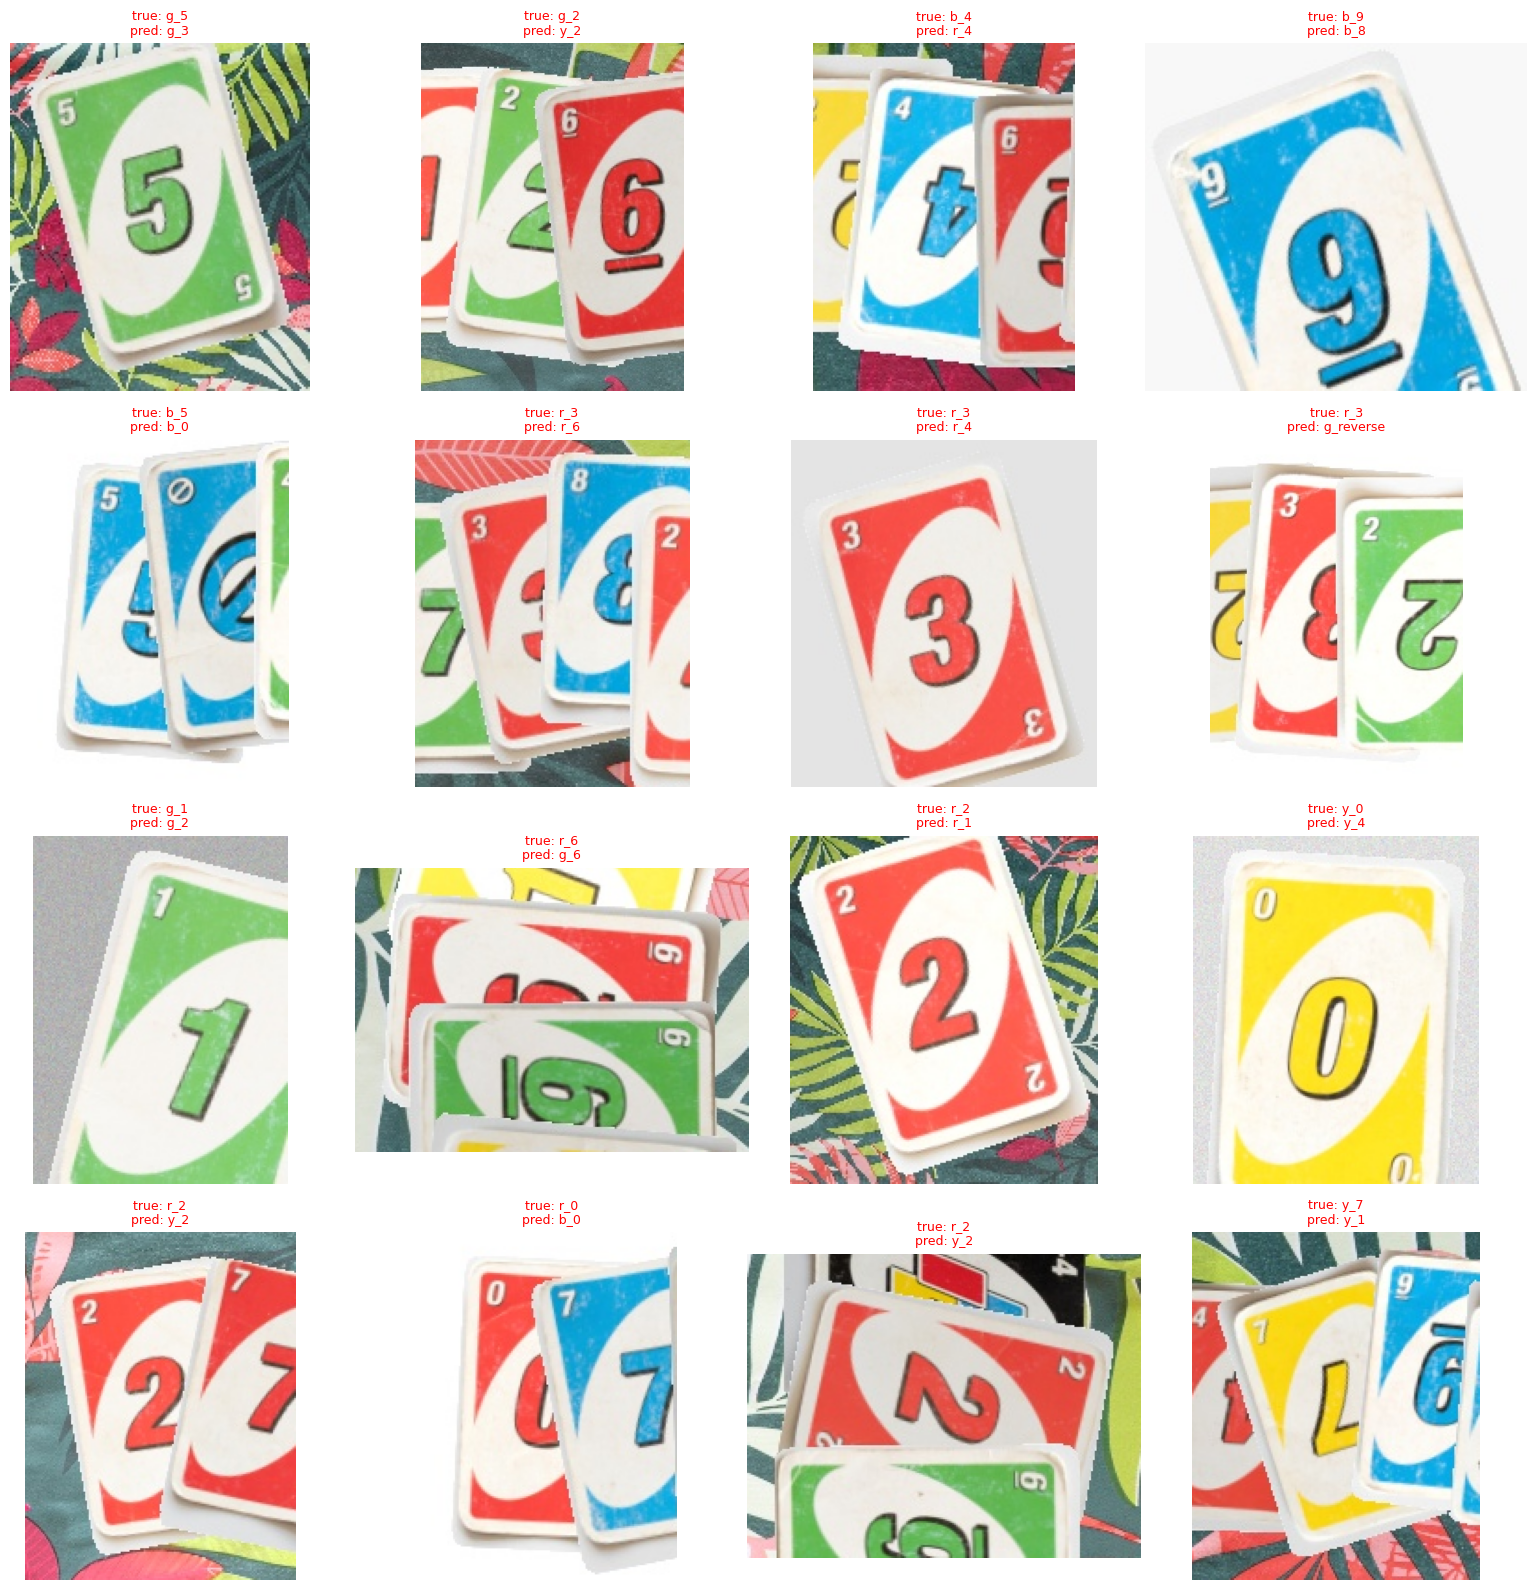

In [33]:
wrong = [
    (sample_index, true_label, pred_label)
    for sample_index, true_label, pred_label in zip(val_idx, true_labels, pred_labels)
    if true_label != pred_label
]

print(f"Wrong validation predictions: {len(wrong)} / {len(val_idx)}")

if wrong:
    show_count = min(16, len(wrong))
    cols = 4
    rows = int(np.ceil(show_count / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (sample_index, true_label, pred_label) in zip(axes, wrong[:show_count]):
        sample = valid_samples[int(sample_index)]
        img_bgr = read_sample_bgr(sample)
        ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(f"true: {true_label}\npred: {pred_label}", color="red", fontsize=9)
        ax.axis("off")

    for ax in axes[show_count:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()